In [21]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("global-data-on-sustainable-energy (1).csv")

In [23]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [24]:
from scipy.stats import linregress


In [25]:
print(df["Year"].isna().sum())
print(df["Access to electricity (% of population)"].isna().sum())

0
10


In [26]:
df["Access to electricity (% of population)"] = df["Access to electricity (% of population)"].fillna(0)

In [27]:
print(df["Year"].isna().sum())
print(df["Access to electricity (% of population)"].isna().sum())

0
0


In [28]:
#Testing whether access to electricty increases as time progresses. 
#Null hypothesis: Time has no effect on access to electricity 
#Alternative hypothesis: As time increases, access to electricity increases.

In [29]:
x = df["Year"]
y = df["Access to electricity (% of population)"]


result = linregress(x, y)

print("Slope:", result.slope)
print("P-value:", result.pvalue)
print("R-squared:", result.rvalue**2)

Slope: 0.6684141774362693
P-value: 8.70913824058427e-16
R-squared: 0.017587308803548453


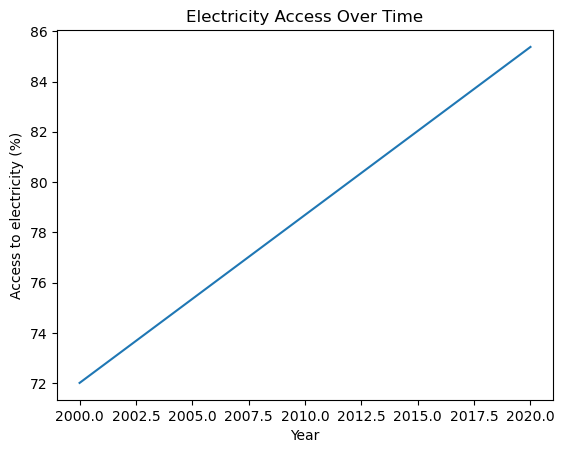

In [30]:
plt.plot(x, result.intercept + result.slope*x)

plt.xlabel("Year")
plt.ylabel("Access to electricity (%)")
plt.title("Electricity Access Over Time")

plt.show()

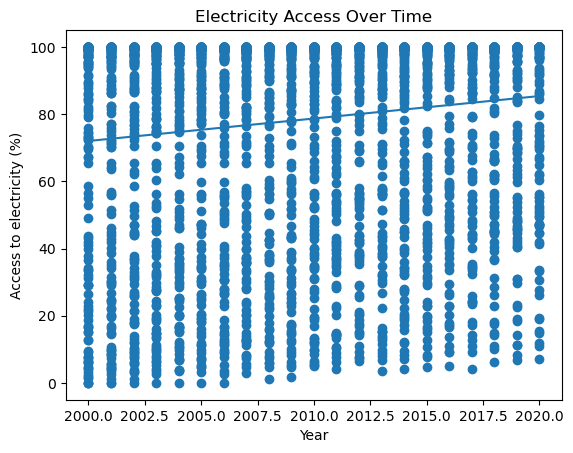

In [31]:
#Why R-squared value is so low
plt.scatter(x, y)
plt.plot(x, result.intercept + result.slope*x)

plt.xlabel("Year")
plt.ylabel("Access to electricity (%)")
plt.title("Electricity Access Over Time")

plt.show()

In [32]:
#Since the data set has so many scatter points for each country there is huge variance between them
#resulting in low r-squared value as many points are away from the line of best fit

In [34]:
from sklearn.linear_model import LinearRegression

df = df.fillna(0)

# dependent variable
y = df["Access to electricity (% of population)"]

# independent variables
X = df[["Financial flows to developing countries (US $)", "gdp_per_capita"]]

model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R-squared:", model.score(X, y))

Intercept: 70.94298275104312
Coefficients: [1.52715457e-09 6.29254301e-04]
R-squared: 0.15720412941229445


In [35]:
#interpretation of coefficients: An additional 1 billion $ in financial flows is 
#associated with roughly a 1.53% increase in electricity access. And 1000$ increase in 
#GDP per capita is associated with a 0.63% increase in electricity access

In [42]:
import sys 
print(sys.version)



3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
